# Лабораторна робота 5. Метод опорних векторів (SVM). Методи оцінки якості моделі

### Дисципліна: Розпізнавання образів та комп'ютерний зір
### Група: КІ-22-1
### Студент: Савченко Андрій Олександрович

## Завдання для самостійної роботи

### 1. Реалізувати SVM-класифікатор з лінійним і різними нелінійним ядрами згідно з варіантом.
### 2. Проаналізувати іпорівняти результати класифікації, обчисливши відповідні метрики.
### 3. Вибрати найкращу модель. Результат обґрунтувати.
### 4. Дати відповіді на контрольні запитання.
### 5. Відправити результати роботи у файлі lab_5_StudentLastName.ipynb до віддаленого репозиторію на GіtHub

## Варіант індивідульного завдання

Варіант 9:
x_train_9:
<br> [[37 46]
<br>  [26 50]
<br>  [23  6]
<br>  [21 33]
<br>  [36 42]
<br>  [37 44]
<br>  [19  6]
<br>  [23  5]
<br>  [35 28]]
<br> y_train_9:
<br> [ 1 -1  1  1 -1  1 -1  1  1]

Метрики класифікації:

Лінійне
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0

RBF
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0

Поліноміальне
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0

Sigmoid
Accuracy: 0.4
Precision: 0.3333333333333333
Recall: 0.2
F1: 0.25

Найкраща модель: Лінійне


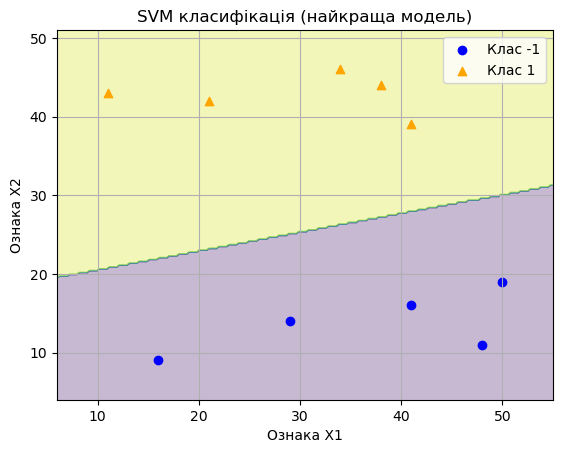

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

x_train = np.array([[16, 9],
                    [38, 44],
                    [29, 14],
                    [41, 16],
                    [50, 19],
                    [48, 11],
                    [11, 43],
                    [21, 42],
                    [41, 39],
                    [34, 46]])

y_train = np.array([-1, 1, -1, -1, -1, -1, 1, 1, 1, 1])

kernels = {
    "Лінійне": SVC(kernel='linear'),
    "RBF": SVC(kernel='rbf'),
    "Поліноміальне": SVC(kernel='poly', degree=3),
    "Sigmoid": SVC(kernel='sigmoid')
}

results = {}

print("Метрики класифікації:\n")

for name, model in kernels.items():

    model.fit(x_train, y_train)

    y_pred = model.predict(x_train)

    acc = accuracy_score(y_train, y_pred)
    prec = precision_score(y_train, y_pred)
    rec = recall_score(y_train, y_pred)
    f1 = f1_score(y_train, y_pred)

    results[name] = acc

    print(name)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)
    print()

best_model = max(results, key=results.get)

print("Найкраща модель:", best_model)

model = kernels[best_model]

x_min, x_max = x_train[:,0].min()-5, x_train[:,0].max()+5
y_min, y_max = x_train[:,1].min()-5, x_train[:,1].max()+5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure()

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(x_train[y_train == -1][:,0],
            x_train[y_train == -1][:,1],
            color="blue",
            marker="o",
            label="Клас -1")

plt.scatter(x_train[y_train == 1][:,0],
            x_train[y_train == 1][:,1],
            color="orange",
            marker="^",
            label="Клас 1")

plt.title("SVM класифікація (найкраща модель)")
plt.xlabel("Ознака X1")
plt.ylabel("Ознака X2")

plt.legend()
plt.grid(True)

plt.show()

## Контрольні питання

### 1. Як виглядає оптимальна гіперплощина в лінійно подільному випадку?
<br> Оптимальною вважається гіперплощина, яка максимізує відступ (margin) між найближчими точками різних класів. Ці найближчі точки називаються опорними векторами.
<br> Математично це виглядає як розв'язання задачі мінімізації:$\frac{1}{2} \|w\|^2 \to \min$
### 2. Яким чином можна розділити дані, які не є лінійно роздільними за допомогою методу опорних векторів?
<br> М’який відступ (Soft Margin) - введення штрафних змінних $\xi$ (slack variables), які дозволяють деяким точкам порушувати межу або навіть опинятися на "чужій" території.
<br> Ядровий метод (Kernel Trick) - відображення даних у простір вищої розмірності, де вони стають лінійно роздільними.
### 3. Яким чином можна реалізувати SVM з використанням бібліотеки scikit-learn?
<br> ` from sklearn.svm import SVC `
<br> `  model = SVC(kernel='rbf', C=1.0) `
<br> ` model.fit(X_train, y_train) `
<br> ` predictions = model.predict(X_test) `
### 4. Як обчислюються показники precision і recall для моделі SVM?
<br> Ці метрики базуються на матриці помилок (Confusion Matrix):
 - Precision (Точність) - частка справді позитивних серед усіх, які модель позначила як позитивні.$$Precision = \frac{TP}{TP + FP}$$
 - Recall (Повнота) - частка знайдених позитивних об'єктів серед усіх справді позитивних.$$Recall = \frac{TP}{TP + FN}$$
### 5. Як обчислюється індекс Джині та яку інформацію він надає про модель?
<br> Індекс Джині найчастіше використовується в деревах рішень для оцінки "забрудненості" (impurity) вузла. Він показує ймовірність того, що випадково обраний елемент буде класифікований неправильно.$$Gini = 1 - \sum_{i=1}^{n} p_i^2$$
### 6. Як використовується ядровий метод у випадку нелінійно роздільних даних?
<br> Суть методу - перетворення $x \to \phi(x)$. Замість того, щоб явно обчислювати координати у високій розмірності (що дорого), ми обчислюємо ядерну функцію $K(x_i, x_j) = \phi(x_i)^T \phi(x_j)$.
<br> Популярні ядра:
 - Поліноміальне: $K(x, y) = (x^T y + c)^d$
 - Гаусове (RBF): $K(x, y) = \exp(-\gamma \|x - y\|^2)$
### 7. Як виглядає процес навчання та передбачення за допомогою SVM?
<br> Навчання - алгоритм розв'язує задачу квадратичного програмування, щоб знайти ваги $w$ та зміщення $b$, які максимізують відступ. Визначаються опорні вектори.
<br> Передбачення - для нової точки $x$ обчислюється знак функції $f(x) = \text{sign}(w^T x + b)$. Якщо результат $+1$ — один клас, якщо $-1$ — інший.